In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
dataset_path = "../Dataset/RAVDESS"

print("Dataset Path:", dataset_path)
print(os.listdir(dataset_path)[:5])

Dataset Path: ../Dataset/RAVDESS
['.ipynb_checkpoints', 'actor_01', 'actor_02', 'actor_03', 'actor_04']


total_files = 0

for actor in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path):

        files = os.listdir(actor_path)

        print(actor, ":", len(files), "files")

        total_files += len(files)

print("\nTotal Audio Files:", total_files)

In [4]:
import os

audio_file = "../Dataset/RAVDESS/actor_01/03-01-01-01-01-01-01.wav"

print(os.path.exists(audio_file))

True


In [6]:
audio, sample_rate = librosa.load(audio_file)

print("Sample Rate:", sample_rate)
print("Audio Length:", len(audio))

Sample Rate: 22050
Audio Length: 72838


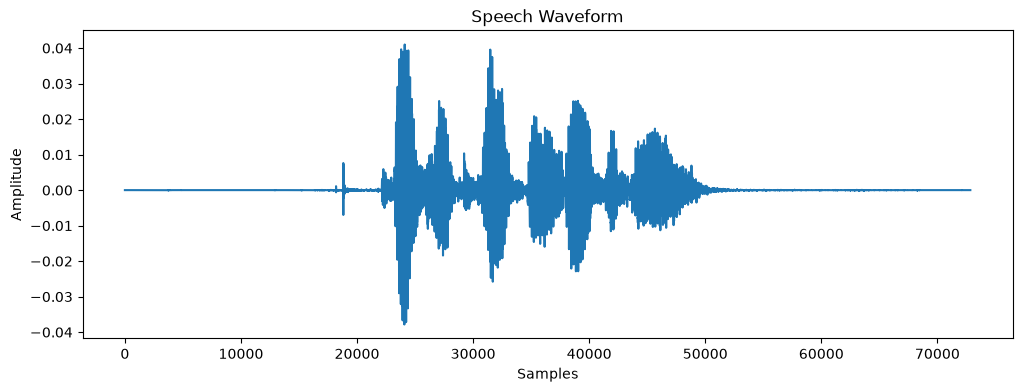

In [7]:
plt.figure(figsize=(12,4))
plt.plot(audio)
plt.title("Speech Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [8]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (40, 143)


In [9]:
import os
import librosa
import numpy as np

features = []
labels = []

emotion_dict = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fear",
    "07": "Disgust",
    "08": "Surprise"
}

dataset_path = "../Dataset/RAVDESS"

for actor in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor)

    if not os.path.isdir(actor_path):
        continue

    for file in os.listdir(actor_path):

        if file.endswith(".wav"):

            file_path = os.path.join(actor_path, file)

            audio, sample_rate = librosa.load(file_path, sr=None)

            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=sample_rate,
                n_mfcc=40
            )

            mfcc = np.mean(mfcc.T, axis=0)

            emotion = file.split("-")[2]

            features.append(mfcc)
            labels.append(emotion_dict[emotion])

print("Total Samples:", len(features))
print("Total Labels :", len(labels))

Total Samples: 1440
Total Labels : 1440


In [10]:
X = np.array(features)
y = np.array(labels)

print("Feature Shape :", X.shape)
print("Label Shape :", y.shape)

Feature Shape : (1440, 40)
Label Shape : (1440,)


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Encoded Labels:")
print(y[:10])

Encoded Labels:
[5 5 5 5 1 1 1 1 1 1]


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (1152, 40)
Testing Samples : (288, 40)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(256, activation="relu", input_shape=(40,)))
model.add(Dropout(0.3))

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))

model.add(Dense(8, activation="softmax"))

C:\Users\HP\.conda\envs\emotion\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Speech Emotion Model Ready!")

Speech Emotion Model Ready!


In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.1267 - loss: 20.5971 - val_accuracy: 0.1806 - val_loss: 3.1249
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1259 - loss: 5.0961 - val_accuracy: 0.1424 - val_loss: 2.1036
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1389 - loss: 2.5755 - val_accuracy: 0.1181 - val_loss: 2.0807
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1302 - loss: 2.3024 - val_accuracy: 0.1181 - val_loss: 2.0780
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1172 - loss: 2.1564 - val_accuracy: 0.1181 - val_loss: 2.0763
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1380 - loss: 2.1555 - val_accuracy: 0.1181 - val_loss: 2.0756
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1450 - loss: 2.1038 - val_accuracy: 0.1181 - val_loss: 2.0746
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1493 - loss: 2.1092 - val_accuracy: 0.1181 - v

In [16]:
model.save("speech_emotion_model.h5")

print("Speech Emotion Model Saved!")

Speech Emotion Model Saved!


In [17]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'emotion_model.h5', 'facial_emotion_detection.ipynb', 'haarcascade_frontalface_default.xml', 'speech_emotion_detection.ipynb', 'speech_emotion_model.h5']


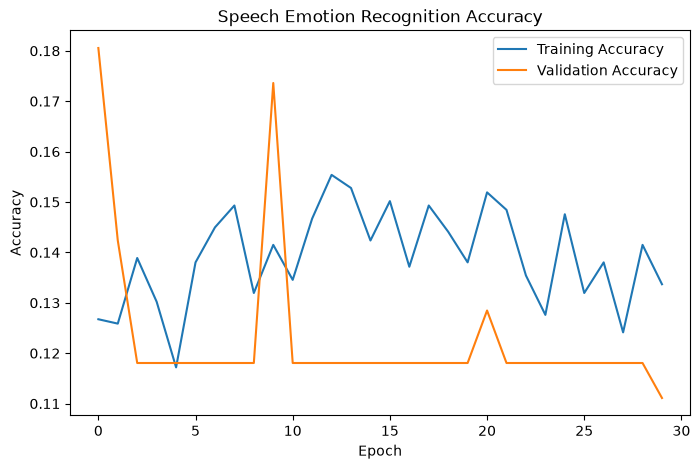

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Speech Emotion Recognition Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [19]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("Unique Labels:", np.unique(y))
print("Number of Classes:", len(np.unique(y)))

X Shape: (1440, 40)
y Shape: (1440,)
Unique Labels: [0 1 2 3 4 5 6 7]
Number of Classes: 8


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Normalization Completed!")
print("New Shape:", X_scaled.shape)

Normalization Completed!
New Shape: (1440, 40)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1152, 40)
(288, 40)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

model_v2 = Sequential([

    Input(shape=(40,)),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(8, activation='softmax')

])

print("Improved Model Created!")

Improved Model Created!


In [23]:
model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Ready!")


Model Ready!


In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True
)

print("Early Stopping Ready!")

Early Stopping Ready!


In [25]:
history_v2 = model_v2.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.2188 - loss: 2.1516 - val_accuracy: 0.3125 - val_loss: 1.9052
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3299 - loss: 1.8022 - val_accuracy: 0.3507 - val_loss: 1.8320
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3941 - loss: 1.6336 - val_accuracy: 0.3542 - val_loss: 1.7747
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4340 - loss: 1.5033 - val_accuracy: 0.3194 - val_loss: 1.7025
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4774 - loss: 1.3834 - val_accuracy: 0.2986 - val_loss: 1.6763
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5330 - loss: 1.2772 - val_accuracy: 0.3889 - val_loss: 1.5718
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5391 - loss: 1.2707 - val_accuracy: 0.4236 - val_loss: 1.4840
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5660 - loss: 1.1763 - val_accuracy: 0.4

In [26]:
model_v2.save("speech_emotion_model_v2.h5")

print("Improved Speech Model Saved!")

Improved Speech Model Saved!


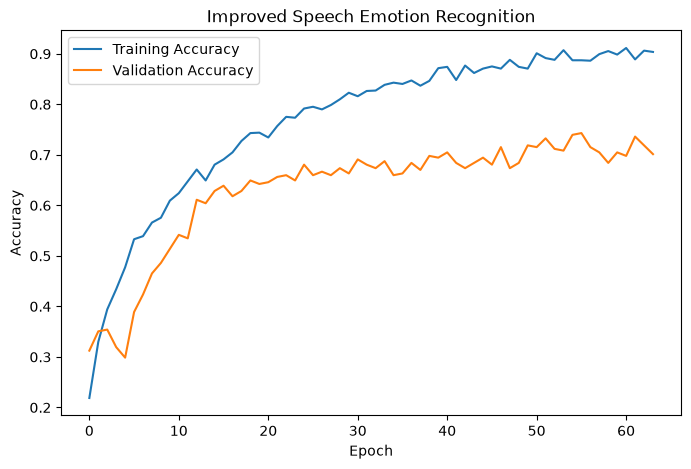

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_v2.history['accuracy'], label='Training Accuracy')
plt.plot(history_v2.history['val_accuracy'], label='Validation Accuracy')

plt.title("Improved Speech Emotion Recognition")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [28]:
loss, accuracy = model_v2.evaluate(X_test, y_test)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7431 - loss: 0.9641 
Final Test Accuracy: 74.31%
